In [206]:
# %pip install lightgbm

In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [208]:
df = pd.read_csv('archive/global_youtube_creator_data_large.csv')

In [209]:
df

,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,2024-09-14 05:08:02,VID_589765,Vlogs,Japanese,PK,873,6826,396,34,31,-0.082,True
1,2025-08-09 12:23:26,VID_577279,Tech Reviews,Urdu,UK,2335,11371,402,26,19,-0.873,False
2,2024-03-04 14:39:48,VID_890301,Gaming,English,BR,1895,7509,730,45,25,-0.764,True
3,2025-05-04 11:05:26,VID_613444,Education,Urdu,PK,841,17361,1302,122,25,-0.788,True
4,2024-09-22 20:22:31,VID_602671,Gaming,Japanese,IN,1246,18494,756,63,42,0.521,False
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2024-06-25 13:51:46,VID_383631,Tech Reviews,Urdu,IN,3052,9019,345,58,9,0.122,True
999996,2025-05-25 06:00:30,VID_415513,Gaming,Japanese,BR,3145,1831,104,12,2,0.043,False
999997,2025-07-16 23:45:41,VID_638447,Gaming,English,US,2269,17,1,0,0,-0.784,False
999998,2025-01-07 21:06:01,VID_177749,Education,Urdu,UK,1351,7355,555,54,34,0.978,True


In [210]:
df.columns

Index(['timestamp', 'video_id', 'category', 'language', 'region',
       'duration_sec', 'views', 'likes', 'comments', 'shares',
       'sentiment_score', 'ads_enabled'],
      dtype='object')

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   timestamp        1000000 non-null  object 
 1   video_id         1000000 non-null  object 
 2   category         1000000 non-null  object 
 3   language         1000000 non-null  object 
 4   region           1000000 non-null  object 
 5   duration_sec     1000000 non-null  int64  
 6   views            1000000 non-null  int64  
 7   likes            1000000 non-null  int64  
 8   comments         1000000 non-null  int64  
 9   shares           1000000 non-null  int64  
 10  sentiment_score  1000000 non-null  float64
 11  ads_enabled      1000000 non-null  bool   
dtypes: bool(1), float64(1), int64(5), object(5)
memory usage: 84.9+ MB


In [212]:
df.shape

(1000000, 12)

In [213]:
df = df.drop(columns=['video_id', 'sentiment_score', 'ads_enabled'])

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   timestamp     1000000 non-null  object
 1   category      1000000 non-null  object
 2   language      1000000 non-null  object
 3   region        1000000 non-null  object
 4   duration_sec  1000000 non-null  int64 
 5   views         1000000 non-null  int64 
 6   likes         1000000 non-null  int64 
 7   comments      1000000 non-null  int64 
 8   shares        1000000 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 68.7+ MB


In [215]:
df

,timestamp,category,language,region,duration_sec,views,likes,comments,shares
0,2024-09-14 05:08:02,Vlogs,Japanese,PK,873,6826,396,34,31
1,2025-08-09 12:23:26,Tech Reviews,Urdu,UK,2335,11371,402,26,19
2,2024-03-04 14:39:48,Gaming,English,BR,1895,7509,730,45,25
3,2025-05-04 11:05:26,Education,Urdu,PK,841,17361,1302,122,25
4,2024-09-22 20:22:31,Gaming,Japanese,IN,1246,18494,756,63,42
...,...,...,...,...,...,...,...,...,...
999995,2024-06-25 13:51:46,Tech Reviews,Urdu,IN,3052,9019,345,58,9
999996,2025-05-25 06:00:30,Gaming,Japanese,BR,3145,1831,104,12,2
999997,2025-07-16 23:45:41,Gaming,English,US,2269,17,1,0,0
999998,2025-01-07 21:06:01,Education,Urdu,UK,1351,7355,555,54,34


In [216]:
df.describe()

,duration_sec,views,likes,comments,shares
count,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000
mean,1829.589053,10012.587052,550.139094,68.34110,29.536169
std,1022.387019,9999.381263,662.291287,90.89229,34.185734
min,60.000000,0.000000,0.000000,0.00000,0.000000
25%,943.000000,2885.000000,121.000000,13.00000,7.000000
50%,1830.000000,6943.000000,321.000000,37.00000,18.000000
75%,2715.000000,13877.000000,727.000000,87.00000,40.000000
max,3599.000000,147139.000000,11970.000000,1795.00000,718.000000


In [217]:
df['duration_sec'].value_counts(bins=10).sort_values()

(2183.4, 2537.3]     99673
(1475.6, 1829.5]     99693
(1121.7, 1475.6]     99778
(1829.5, 2183.4]     99792
(56.46, 413.9]       99944
(3245.1, 3599.0]    100000
(413.9, 767.8]      100080
(2537.3, 2891.2]    100287
(2891.2, 3245.1]    100366
(767.8, 1121.7]     100387
Name: count, dtype: int64

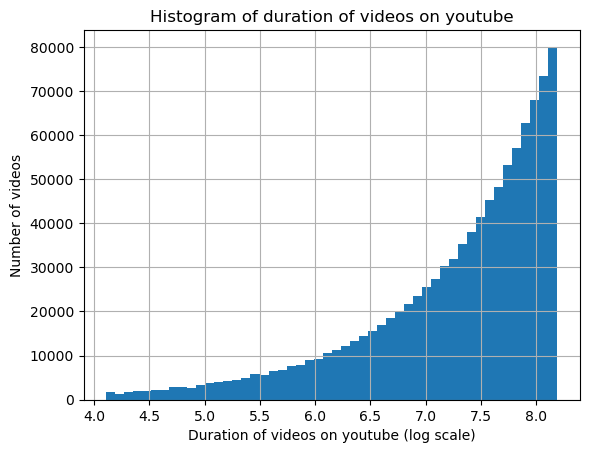

In [218]:
log_duration = np.log1p(df['duration_sec'])
log_duration.hist(bins=50)
plt.title('Histogram of duration of videos on youtube')
plt.xlabel('Duration of videos on youtube (log scale)')
plt.ylabel('Number of videos')
plt.show()

In [219]:
df['views'].value_counts(bins=10).sort_values()

(132425.1, 147139.0]                   3
(117711.2, 132425.1]                   7
(102997.3, 117711.2]                  21
(88283.4, 102997.3]                  103
(73569.5, 88283.4]                   493
(58855.6, 73569.5]                  2210
(44141.7, 58855.6]                  9185
(29427.8, 44141.7]                 40637
(14713.9, 29427.8]                177131
(-147.14000000000001, 14713.9]    770210
Name: count, dtype: int64

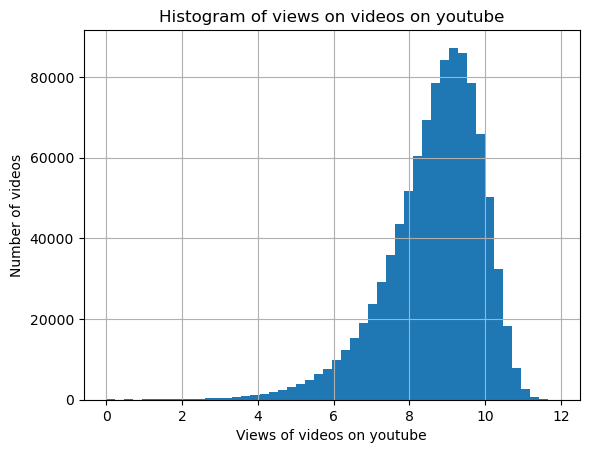

In [220]:
log_views = np.log1p(df['views'])

log_views.hist(bins=50)
plt.title("Histogram of views on videos on youtube")
plt.xlabel('Views of videos on youtube')
plt.ylabel('Number of videos')
plt.show()

In [221]:
df['likes'].value_counts(bins=10).sort_values()

(10773.0, 11970.0]         2
(9576.0, 10773.0]          3
(8379.0, 9576.0]          21
(7182.0, 8379.0]          61
(5985.0, 7182.0]         282
(4788.0, 5985.0]        1085
(3591.0, 4788.0]        4393
(2394.0, 3591.0]       19411
(1197.0, 2394.0]       98588
(-11.971, 1197.0]     876154
Name: count, dtype: int64

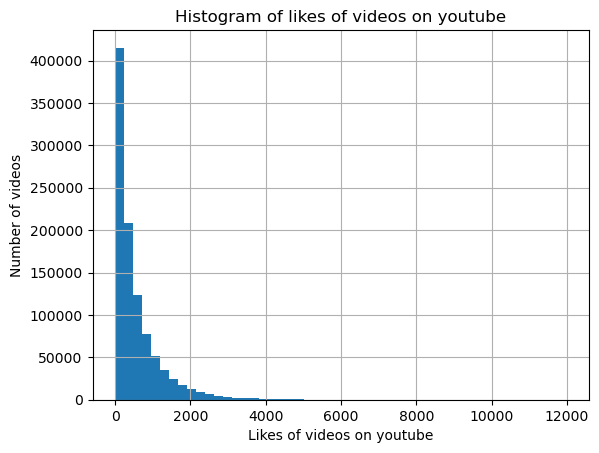

In [222]:
df['likes'].hist(bins=50)

plt.title('Histogram of likes of videos on youtube')
plt.xlabel('Likes of videos on youtube')
plt.ylabel('Number of videos')
plt.show()

In [223]:
df['comments'].value_counts(bins=10).sort_values()

(1615.5, 1795.0]                     3
(1436.0, 1615.5]                     6
(1256.5, 1436.0]                    33
(1077.0, 1256.5]                    88
(897.5, 1077.0]                    265
(718.0, 897.5]                     891
(538.5, 718.0]                    3407
(359.0, 538.5]                   13785
(179.5, 359.0]                   72750
(-1.7959999999999998, 179.5]    908772
Name: count, dtype: int64

In [224]:
df['shares'].value_counts(bins=10).sort_values()

(646.2, 718.0]         1
(574.4, 646.2]         1
(502.6, 574.4]         2
(430.8, 502.6]        22
(359.0, 430.8]        77
(287.2, 359.0]       476
(215.4, 287.2]      2156
(143.6, 215.4]     12683
(71.8, 143.6]      83675
(-0.719, 71.8]    900907
Name: count, dtype: int64

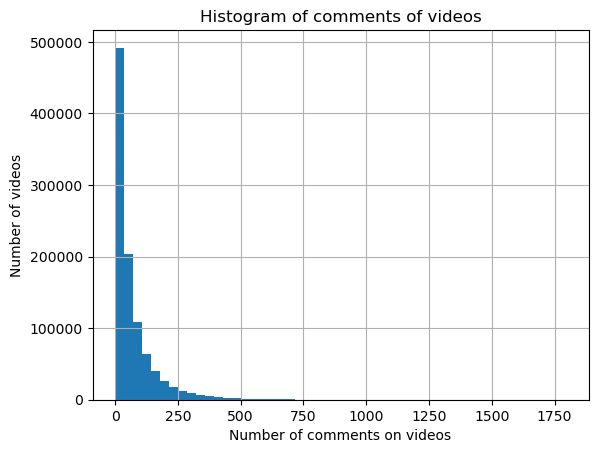

In [225]:
df['comments'].hist(bins=50)

plt.title('Histogram of comments of videos')
plt.ylabel('Number of videos')
plt.xlabel('Number of comments on videos')
plt.show()

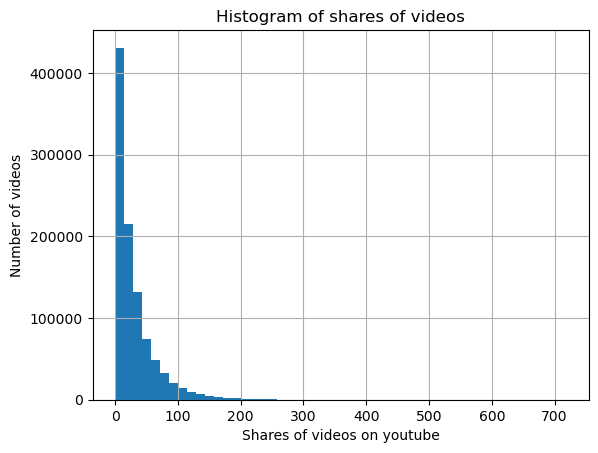

In [226]:
df['shares'].hist(bins=50)

plt.title('Histogram of shares of videos')
plt.xlabel('Shares of videos on youtube')
plt.ylabel('Number of videos')
plt.show()

In [227]:
df = df.drop(columns=['likes', 'comments', 'shares'])

In [228]:
df

,timestamp,category,language,region,duration_sec,views
0,2024-09-14 05:08:02,Vlogs,Japanese,PK,873,6826
1,2025-08-09 12:23:26,Tech Reviews,Urdu,UK,2335,11371
2,2024-03-04 14:39:48,Gaming,English,BR,1895,7509
3,2025-05-04 11:05:26,Education,Urdu,PK,841,17361
4,2024-09-22 20:22:31,Gaming,Japanese,IN,1246,18494
...,...,...,...,...,...,...
999995,2024-06-25 13:51:46,Tech Reviews,Urdu,IN,3052,9019
999996,2025-05-25 06:00:30,Gaming,Japanese,BR,3145,1831
999997,2025-07-16 23:45:41,Gaming,English,US,2269,17
999998,2025-01-07 21:06:01,Education,Urdu,UK,1351,7355


In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   timestamp     1000000 non-null  object
 1   category      1000000 non-null  object
 2   language      1000000 non-null  object
 3   region        1000000 non-null  object
 4   duration_sec  1000000 non-null  int64 
 5   views         1000000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 45.8+ MB


In [230]:
df['category'].unique()

array(['Vlogs', 'Tech Reviews', 'Gaming', 'Education', 'Music', 'Coding'],
      dtype=object)

In [231]:
df['language'].unique()

array(['Japanese', 'Urdu', 'English', 'Spanish', 'Hindi'], dtype=object)

In [232]:
df['region'].unique()

array(['PK', 'UK', 'BR', 'IN', 'US'], dtype=object)

In [233]:
df['category'].value_counts()

category
Vlogs           167383
Education       167073
Coding          166609
Gaming          166401
Music           166381
Tech Reviews    166153
Name: count, dtype: int64

In [234]:
df['region'].value_counts()

region
US    200518
PK    200479
BR    200202
IN    199673
UK    199128
Name: count, dtype: int64

In [235]:
df['language'].value_counts()

language
English     200560
Hindi       200362
Urdu        199887
Spanish     199650
Japanese    199541
Name: count, dtype: int64

In [236]:
df

,timestamp,category,language,region,duration_sec,views
0,2024-09-14 05:08:02,Vlogs,Japanese,PK,873,6826
1,2025-08-09 12:23:26,Tech Reviews,Urdu,UK,2335,11371
2,2024-03-04 14:39:48,Gaming,English,BR,1895,7509
3,2025-05-04 11:05:26,Education,Urdu,PK,841,17361
4,2024-09-22 20:22:31,Gaming,Japanese,IN,1246,18494
...,...,...,...,...,...,...
999995,2024-06-25 13:51:46,Tech Reviews,Urdu,IN,3052,9019
999996,2025-05-25 06:00:30,Gaming,Japanese,BR,3145,1831
999997,2025-07-16 23:45:41,Gaming,English,US,2269,17
999998,2025-01-07 21:06:01,Education,Urdu,UK,1351,7355


In [237]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   timestamp     1000000 non-null  datetime64[ns]
 1   category      1000000 non-null  object        
 2   language      1000000 non-null  object        
 3   region        1000000 non-null  object        
 4   duration_sec  1000000 non-null  int64         
 5   views         1000000 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 45.8+ MB


In [239]:
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_of_week
df['is_weekend'] = df['timestamp'].isin([5, 6]).astype(int)

In [240]:
df

,timestamp,category,language,region,duration_sec,views,year,month,day,hour,day_of_week,is_weekend
0,2024-09-14 05:08:02,Vlogs,Japanese,PK,873,6826,2024,9,14,5,5,0
1,2025-08-09 12:23:26,Tech Reviews,Urdu,UK,2335,11371,2025,8,9,12,5,0
2,2024-03-04 14:39:48,Gaming,English,BR,1895,7509,2024,3,4,14,0,0
3,2025-05-04 11:05:26,Education,Urdu,PK,841,17361,2025,5,4,11,6,0
4,2024-09-22 20:22:31,Gaming,Japanese,IN,1246,18494,2024,9,22,20,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2024-06-25 13:51:46,Tech Reviews,Urdu,IN,3052,9019,2024,6,25,13,1,0
999996,2025-05-25 06:00:30,Gaming,Japanese,BR,3145,1831,2025,5,25,6,6,0
999997,2025-07-16 23:45:41,Gaming,English,US,2269,17,2025,7,16,23,2,0
999998,2025-01-07 21:06:01,Education,Urdu,UK,1351,7355,2025,1,7,21,1,0


In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   timestamp     1000000 non-null  datetime64[ns]
 1   category      1000000 non-null  object        
 2   language      1000000 non-null  object        
 3   region        1000000 non-null  object        
 4   duration_sec  1000000 non-null  int64         
 5   views         1000000 non-null  int64         
 6   year          1000000 non-null  int32         
 7   month         1000000 non-null  int32         
 8   day           1000000 non-null  int32         
 9   hour          1000000 non-null  int32         
 10  day_of_week   1000000 non-null  int32         
 11  is_weekend    1000000 non-null  int64         
dtypes: datetime64[ns](1), int32(5), int64(3), object(3)
memory usage: 72.5+ MB


In [242]:
df = df.drop(columns=['timestamp'])

In [243]:
df.describe()

,duration_sec,views,year,month,day,hour,day_of_week,is_weekend
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0
mean,1829.589053,10012.587052,2024.498482,6.513223,15.707380,11.499485,2.990581,0.0
std,1022.387019,9999.381263,0.499998,3.444908,8.786551,6.923294,2.001126,0.0
min,60.000000,0.000000,2024.000000,1.000000,1.000000,0.000000,0.000000,0.0
25%,943.000000,2885.000000,2024.000000,4.000000,8.000000,5.000000,1.000000,0.0
50%,1830.000000,6943.000000,2024.000000,7.000000,16.000000,12.000000,3.000000,0.0
75%,2715.000000,13877.000000,2025.000000,10.000000,23.000000,17.000000,5.000000,0.0
max,3599.000000,147139.000000,2025.000000,12.000000,31.000000,23.000000,6.000000,0.0


In [244]:
df = df.drop(columns=['is_weekend'])

In [245]:
df

,category,language,region,duration_sec,views,year,month,day,hour,day_of_week
0,Vlogs,Japanese,PK,873,6826,2024,9,14,5,5
1,Tech Reviews,Urdu,UK,2335,11371,2025,8,9,12,5
2,Gaming,English,BR,1895,7509,2024,3,4,14,0
3,Education,Urdu,PK,841,17361,2025,5,4,11,6
4,Gaming,Japanese,IN,1246,18494,2024,9,22,20,6
...,...,...,...,...,...,...,...,...,...,...
999995,Tech Reviews,Urdu,IN,3052,9019,2024,6,25,13,1
999996,Gaming,Japanese,BR,3145,1831,2025,5,25,6,6
999997,Gaming,English,US,2269,17,2025,7,16,23,2
999998,Education,Urdu,UK,1351,7355,2025,1,7,21,1


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   category      1000000 non-null  object
 1   language      1000000 non-null  object
 2   region        1000000 non-null  object
 3   duration_sec  1000000 non-null  int64 
 4   views         1000000 non-null  int64 
 5   year          1000000 non-null  int32 
 6   month         1000000 non-null  int32 
 7   day           1000000 non-null  int32 
 8   hour          1000000 non-null  int32 
 9   day_of_week   1000000 non-null  int32 
dtypes: int32(5), int64(2), object(3)
memory usage: 57.2+ MB


In [247]:
df['log_views'] = np.log1p(df['views'])

In [248]:
df

,category,language,region,duration_sec,views,year,month,day,hour,day_of_week,log_views
0,Vlogs,Japanese,PK,873,6826,2024,9,14,5,5,8.828641
1,Tech Reviews,Urdu,UK,2335,11371,2025,8,9,12,5,9.338909
2,Gaming,English,BR,1895,7509,2024,3,4,14,0,8.923991
3,Education,Urdu,PK,841,17361,2025,5,4,11,6,9.762039
4,Gaming,Japanese,IN,1246,18494,2024,9,22,20,6,9.825256
...,...,...,...,...,...,...,...,...,...,...,...
999995,Tech Reviews,Urdu,IN,3052,9019,2024,6,25,13,1,9.107200
999996,Gaming,Japanese,BR,3145,1831,2025,5,25,6,6,7.513164
999997,Gaming,English,US,2269,17,2025,7,16,23,2,2.890372
999998,Education,Urdu,UK,1351,7355,2025,1,7,21,1,8.903272


In [249]:
categorical_cols = ['category', 'language', 'region']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [250]:
df

,category,language,region,duration_sec,views,year,month,day,hour,day_of_week,log_views
0,Vlogs,Japanese,PK,873,6826,2024,9,14,5,5,8.828641
1,Tech Reviews,Urdu,UK,2335,11371,2025,8,9,12,5,9.338909
2,Gaming,English,BR,1895,7509,2024,3,4,14,0,8.923991
3,Education,Urdu,PK,841,17361,2025,5,4,11,6,9.762039
4,Gaming,Japanese,IN,1246,18494,2024,9,22,20,6,9.825256
...,...,...,...,...,...,...,...,...,...,...,...
999995,Tech Reviews,Urdu,IN,3052,9019,2024,6,25,13,1,9.107200
999996,Gaming,Japanese,BR,3145,1831,2025,5,25,6,6,7.513164
999997,Gaming,English,US,2269,17,2025,7,16,23,2,2.890372
999998,Education,Urdu,UK,1351,7355,2025,1,7,21,1,8.903272


In [251]:
features = [
    'duration_sec',
]

X = df[features]
y = df['log_views']
y_binned = pd.qcut(y, q=10, labels=False)

In [252]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size =0.2, stratify=y_binned, random_state=42
)

In [253]:
model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.005,
    random_state=42,
    n_jobs=-1,
    max_depth=-1,
)

model.fit(X_train, y_train, categorical_feature='category')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 800000, number of used features: 1
[LightGBM] [Info] Start training from score 8.636326


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.005
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [254]:
y_pred = model.predict(X_test)

In [255]:
print(np.sqrt(mean_squared_error(y_test, y_pred)))

1.2822341183691301


In [256]:
print(r2_score(y_test, y_pred))

-0.00022447438304151746
